In [2]:
import pandas as pd
df = pd.read_csv('smartcart_customers.csv')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Data Preprocessing

### 1.Missing values handle

In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())

### Feature Engineering

In [7]:
df['Age'] = 2026 - df['Year_Birth']

In [8]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

refernece_date = df['Dt_Customer'].max()

df['customer_tenure_days'] = (refernece_date - df['Dt_Customer']).dt.days

In [9]:
# spending

# total_spending = wines+fruits+meet+fish+sweet+gold
df['total_spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# total_children = kids + teens
df['total_children'] = df['Kidhome'] + df['Teenhome']

In [10]:
# Education

df['Education'] = df['Education'].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [11]:
# Marital Status


df['Living_with'] = df['Marital_Status'].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"    
})

In [12]:
 df['Living_with'].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2240 non-null   int64         
 1   Year_Birth            2240 non-null   int64         
 2   Education             2240 non-null   object        
 3   Marital_Status        2240 non-null   object        
 4   Income                2240 non-null   float64       
 5   Kidhome               2240 non-null   int64         
 6   Teenhome              2240 non-null   int64         
 7   Dt_Customer           2240 non-null   datetime64[ns]
 8   Recency               2240 non-null   int64         
 9   MntWines              2240 non-null   int64         
 10  MntFruits             2240 non-null   int64         
 11  MntMeatProducts       2240 non-null   int64         
 12  MntFishProducts       2240 non-null   int64         
 13  MntSweetProducts  

### Drop Columns

In [14]:
cols = ['ID', 'Year_Birth', 'Marital_Status','Kidhome','Teenhome','Dt_Customer']
spending_cols = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [15]:
df_cleaned.shape

(2240, 15)

In [16]:
df.shape

(2240, 27)

### Outliers

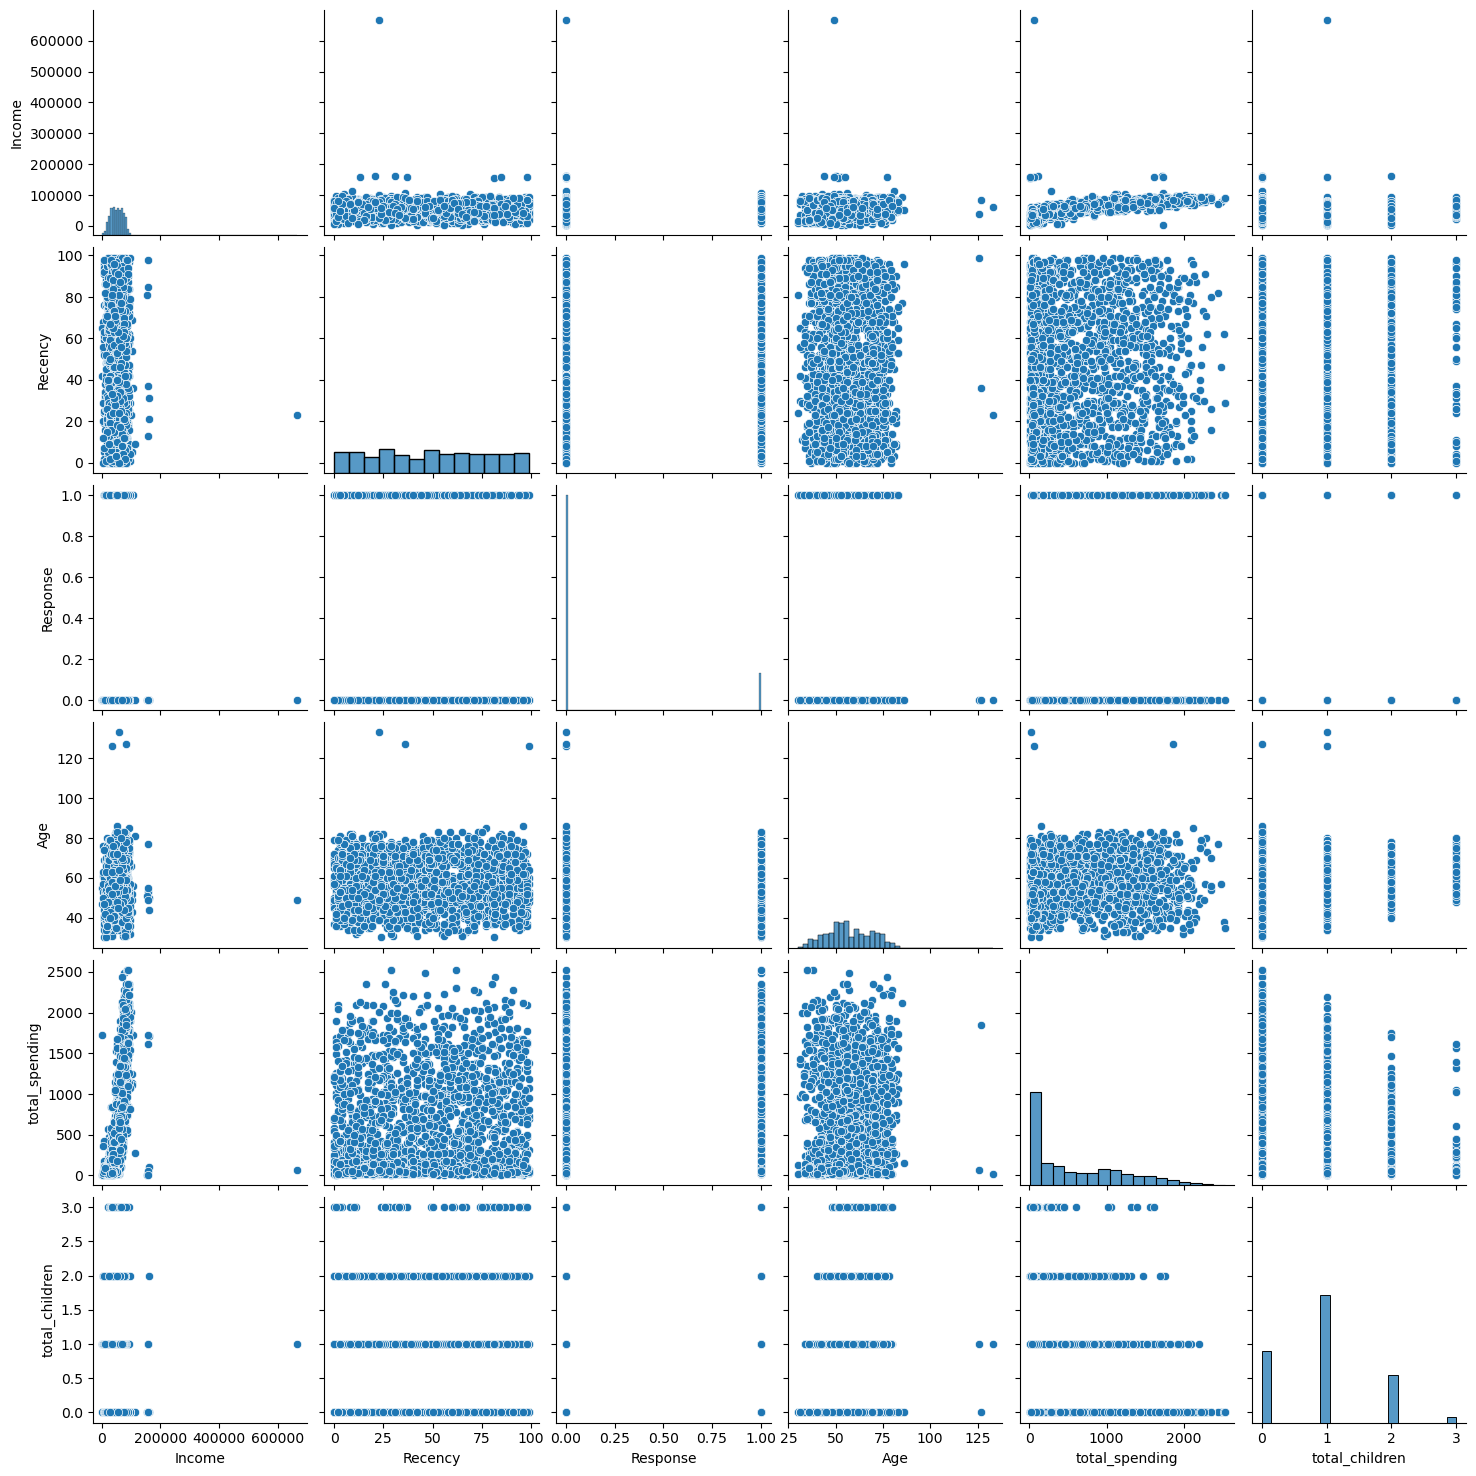

In [17]:
cols = ['Income', 'Recency', 'Response', 'Age', 'total_spending', 'total_children']

# relative plots of some features -pair plots
import seaborn as sns

sns.pairplot(df_cleaned[cols])

In [18]:
# Remove outliers 

print("data size with outliers :", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned['Age'] < 90)]
df_cleaned = df_cleaned[(df_cleaned['Income'] < 600_000)]

print("data size without outliers :", len(df_cleaned))

data size with outliers : 2240
data size without outliers : 2236


### Heatmap

<Axes: >

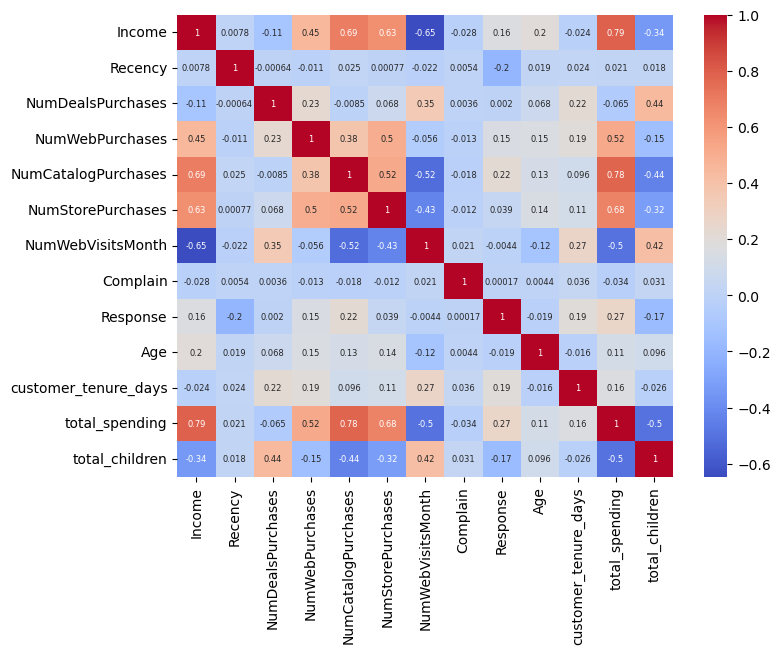

In [19]:
import matplotlib.pyplot as plt
# Correlation of features
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':6},
    cmap='coolwarm'
)

# Encoding and scaling


In [20]:
from sklearn.preprocessing import OneHotEncoder


In [21]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [22]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [23]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [24]:
X = df_encoded

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### visualise

In [27]:
# 2D 
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

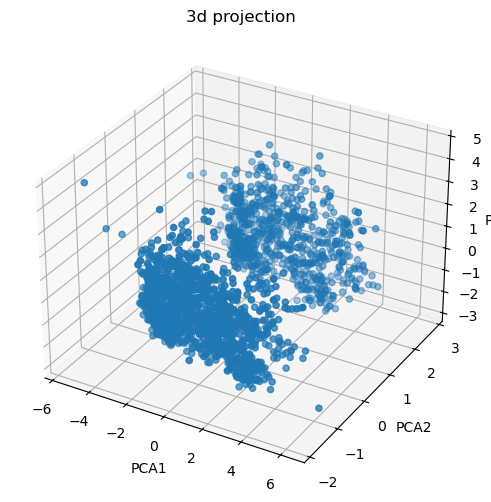

In [28]:
# plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")


### Analyze k value

#### 1.Elbow method

In [29]:
from kneed import KneeLocator
from sklearn.cluster import KMeans

In [30]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [31]:
knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow

In [32]:
print('best k:', optimal_k)

best k: 4


Text(0, 0.5, 'wcss')

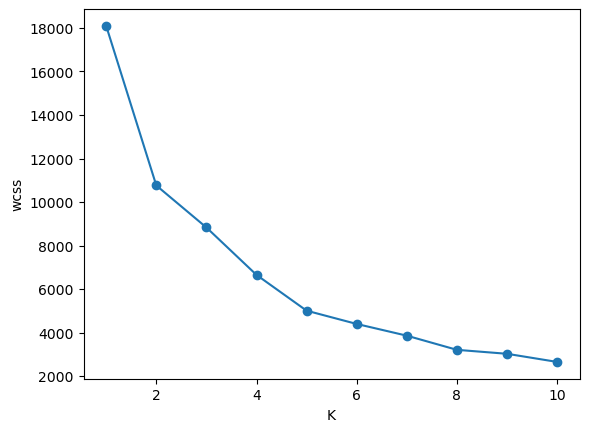

In [33]:
# plot

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

In [34]:
from sklearn.metrics import silhouette_score

In [35]:
ss = []

for k in range(2,11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    ss.append(score)

Text(0, 0.5, 'ss')

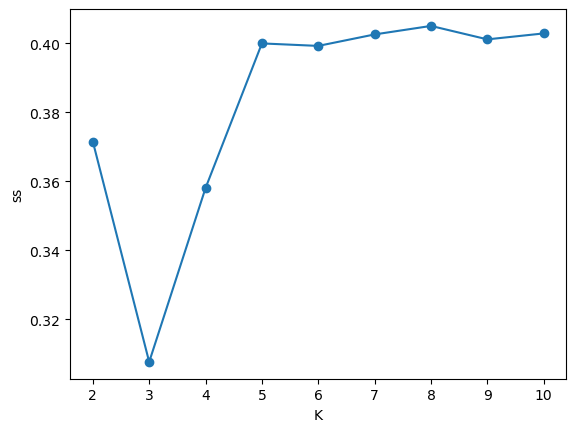

In [36]:
# plot

plt.plot(range(2,11), ss, marker='o')
plt.xlabel("K")
plt.ylabel("ss")

Text(0, 0.5, 'Silhoueete score')

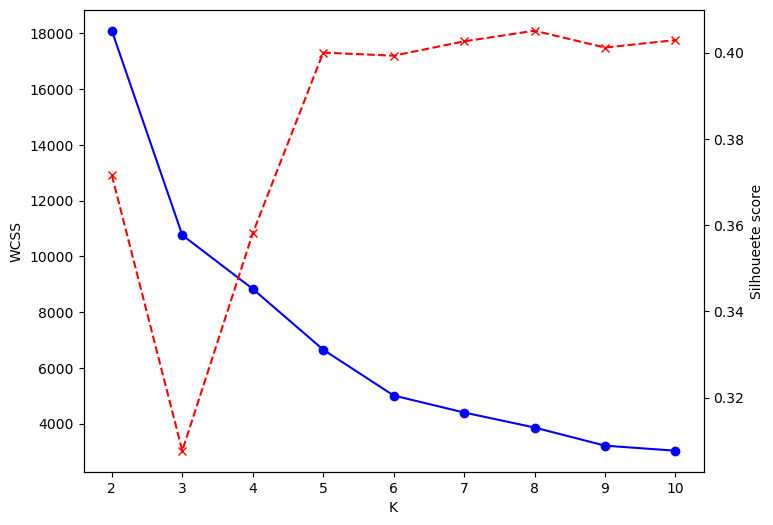

In [37]:
# combined plot of both

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color='blue')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, ss[:len(k_range)], marker='x', color='red', linestyle='--')
ax2.set_ylabel("Silhoueete score")

### Clustering

In [38]:
# K_means
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

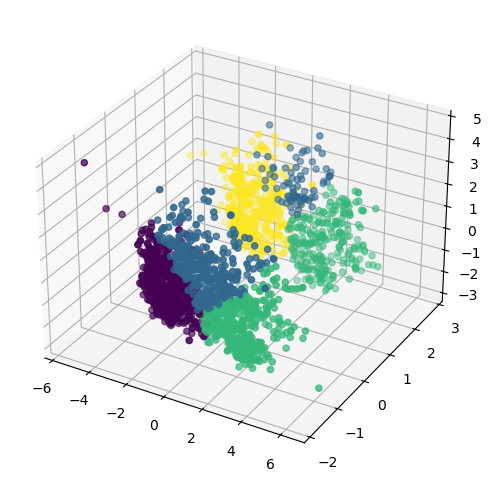

In [39]:
# plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)



In [40]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

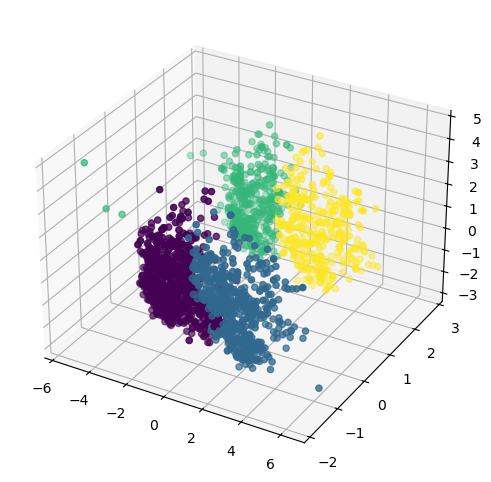

In [41]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

### Charcterisation of clusters

In [53]:
#X.drop('labels', axis=1)
X['cluster'] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

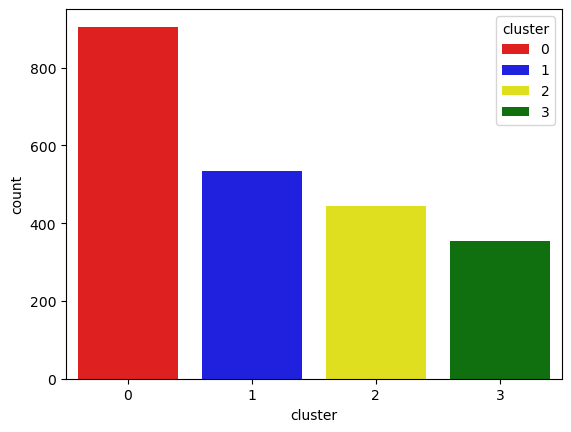

In [54]:
pal = ['red', 'blue', 'yellow', 'green']

sns.countplot(x=X['cluster'], palette=pal, hue=X['cluster'])

<Axes: xlabel='total_spending', ylabel='Income'>

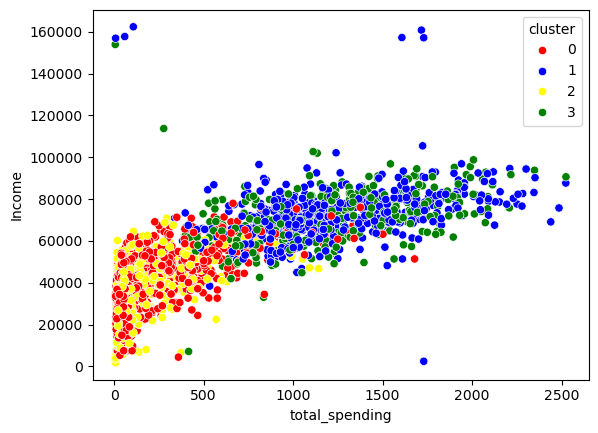

In [56]:
# Income & spending patterns

sns.scatterplot(x=X['total_spending'], y=X['Income'], hue=X['cluster'], palette=pal)

In [58]:
# Cluster summary

cluster_summary = X.groupby('cluster').mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  customer_tenure_days  total_spending  \
cluster         